In [203]:
import torch

def chebyshev_cgl(N, device="cpu"):
    j = torch.arange(0, N+1, device=device)
    x = torch.cos(torch.pi * j / N)
    return x


def chebyshev_diff_matrix(N, device="cpu"):
    x = chebyshev_cgl(N, device)
    
    c = torch.ones(N+1, device=device)
    c[0] = 2.0
    c[-1] = 2.0
    
    X = x.unsqueeze(0)
    dX = X.T - X
    
    C = c.unsqueeze(0)
    C_ratio = C.T / C
    
    i = torch.arange(N+1, device=device)
    sign = (-1.0) ** (i.unsqueeze(0) + i.unsqueeze(1))
    
    dX = dX + torch.eye(N+1, device=device)
    
    D = C_ratio * sign / dX
    
    # Fix diagonal
    D = D - torch.diag(torch.sum(D, dim=1))
    
    return x, D

In [204]:
N = 20
x, D = chebyshev_diff_matrix(N)

u = torch.sin(torch.pi * x)
ux_true = torch.pi * torch.cos(torch.pi * x)
ux_pred = D @ u

rel_error = torch.norm(ux_pred - ux_true) / torch.norm(ux_true)
print("Relative derivative error:", rel_error.item())

Relative derivative error: 4.234028949667845e-07


ux​=Du

In [205]:
def chebyshev_basis(x, K):
    # x_clamped = torch.clamp(x, -1.0 + 1e-12, 1.0 - 1e-12)
    
    theta = torch.arccos(x)
    
    k = torch.arange(0, K, device=x.device, dtype=x.dtype)
    
    Phi = torch.cos(theta.unsqueeze(1) * k.unsqueeze(0))
    
    return Phi

In [206]:
K = 10
Phi = chebyshev_basis(x, K)

print("Phi shape:", Phi.shape)
print("T0 check:", torch.allclose(Phi[:, 0], torch.ones_like(x)))
print("T1 error:", torch.norm(Phi[:, 1] - x).item())

Phi shape: torch.Size([21, 10])
T0 check: True
T1 error: 0.0


In [207]:
def compute_pde_residual(D, Phi, c, f):
    u = Phi @ c
    
    D2 = D @ D
    u_xx = D2 @ u
    
    r_pde = -u_xx - f
    
    return r_pde, u

In [208]:
def compute_bc_residual(u, g_left=0.0, g_right=0.0):
    return torch.stack([
        u[0] - g_left,
        u[-1] - g_right
    ])

In [209]:
def compute_full_residual(D, Phi, c, f, bc_weight=1.0):
    r_pde, u = compute_pde_residual(D, Phi, c, f)
    r_bc = compute_bc_residual(u)
    
    r_bc = bc_weight * r_bc
    
    r = torch.cat([r_pde, r_bc])
    
    return r, u

In [210]:
def build_A(D, bc_weight=1.0):
    Np1 = D.shape[0]
    
    D2 = D @ D
    A_pde = -D2
    
    A_bc = torch.zeros(2, Np1, device=D.device, dtype=D.dtype)
    A_bc[0, 0] = bc_weight
    A_bc[1, -1] = bc_weight
    
    A = torch.cat([A_pde, A_bc], dim=0)
    
    return A

In [211]:
import torch.nn as nn

class CoeffNet(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8),
            nn.Tanh(),
            nn.Linear(8, 8),
            nn.Tanh(),
            nn.Linear(8, K)
        )
    
    def forward(self):
        x = torch.ones(1, 1)
        return self.net(x).squeeze()

In [212]:
def build_B(model):
    """
    Builds B = dc/dtheta
    
    Returns:
        B : (K, P)
    """
    c = model()  # (K,)
    K = c.shape[0]
    
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    
    B = torch.zeros(K, P, device=c.device, dtype=c.dtype)
    
    for k in range(K):
        model.zero_grad()
        
        c[k].backward(retain_graph=True)
        
        grads = []
        for p in params:
            grads.append(p.grad.view(-1))
        
        B[k] = torch.cat(grads)
    
    return B

In [213]:
model = CoeffNet(K)
B = build_B(model)

print("B shape:", B.shape)

B shape: torch.Size([10, 178])


In [214]:
def build_J(model, D, Phi, bc_weight=1.0):
    A = build_A(D, bc_weight)
    B = build_B(model)
    
    J = A @ Phi @ B
    
    return J

In [215]:
J = build_J(model, D, Phi)

print("J shape:", J.shape)

J shape: torch.Size([23, 178])


In [216]:
def compute_r(model, D, Phi, f, bc_weight=1.0):
    c = model()
    r, u = compute_full_residual(D, Phi, c, f, bc_weight)
    return r, u, c

In [ ]:
def gauss_newton_step(model, D, Phi, f, bc_weight=1.0, mu=1e-3):
    r, u, c = compute_r(model, D, Phi, f, bc_weight)
    
    J = build_J(model, D, Phi, bc_weight)
    
    JTJ = J.T @ J
    JTr = J.T @ r
    
    # Damping (LM)
    mu_scaled = mu * torch.trace(JTJ) / JTJ.shape[0]
    
    JTJ = JTJ + mu_scaled * torch.eye(JTJ.shape[0], device=JTJ.device)
    
    delta_theta = -torch.linalg.solve(JTJ, JTr)
    
    return delta_theta, r , JTJ

In [218]:
def update_model(model, delta_theta, alpha=0.1):
    params = list(model.parameters())
    
    idx = 0
    for p in params:
        numel = p.numel()
        
        delta = delta_theta[idx:idx+numel].view_as(p)
        
        p.data += alpha * delta
        
        idx += numel

In [225]:
import matplotlib.pyplot as plt

# Problem setup
K = 10
model = CoeffNet(K)

# True function
f = (torch.pi**2) * torch.sin(torch.pi * x)

loss_history = []


for i in range(300):
    delta_theta, r , JTJ = gauss_newton_step(model, D, Phi, f, bc_weight=10.0)
    
    update_model(model, delta_theta, alpha=0.1)
    
    loss = torch.norm(r).item()
    loss_history.append(loss)
    
    print(f"Iter {i}: Loss = {loss}")
    
    print(JTJ.shape)
    
    # if i==299:
    #     print("JTJ at iter 45:", JTJ[:5, :5])  # Print top-left 5x5 block of JTJ for inspection

Iter 0: Loss = 918.6165771484375
torch.Size([178, 178])
Iter 1: Loss = 827.5521240234375
torch.Size([178, 178])
Iter 2: Loss = 745.117431640625
torch.Size([178, 178])
Iter 3: Loss = 670.5796508789062
torch.Size([178, 178])
Iter 4: Loss = 603.2733154296875
torch.Size([178, 178])
Iter 5: Loss = 542.5671997070312
torch.Size([178, 178])
Iter 6: Loss = 487.8708801269531
torch.Size([178, 178])
Iter 7: Loss = 438.6305847167969
torch.Size([178, 178])
Iter 8: Loss = 394.33154296875
torch.Size([178, 178])
Iter 9: Loss = 354.4978332519531
torch.Size([178, 178])
Iter 10: Loss = 318.6911926269531
torch.Size([178, 178])
Iter 11: Loss = 286.5086364746094
torch.Size([178, 178])
Iter 12: Loss = 257.5878601074219
torch.Size([178, 178])
Iter 13: Loss = 231.60092163085938
torch.Size([178, 178])
Iter 14: Loss = 208.24853515625
torch.Size([178, 178])
Iter 15: Loss = 187.2608184814453
torch.Size([178, 178])
Iter 16: Loss = 168.4001922607422
torch.Size([178, 178])
Iter 17: Loss = 151.44732666015625
torch.Size

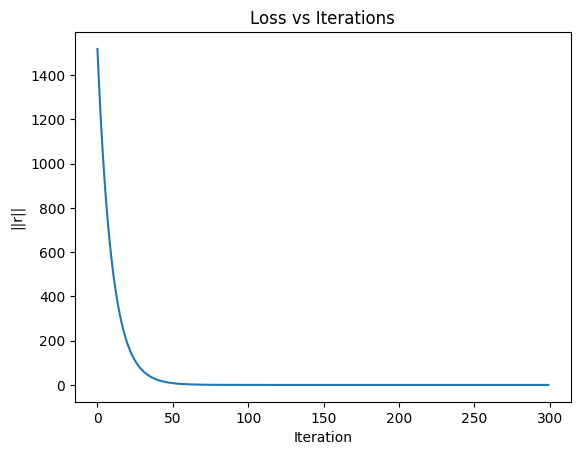

In [220]:
plt.figure()
plt.plot(loss_history)
plt.title("Loss vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("||r||")
plt.show()

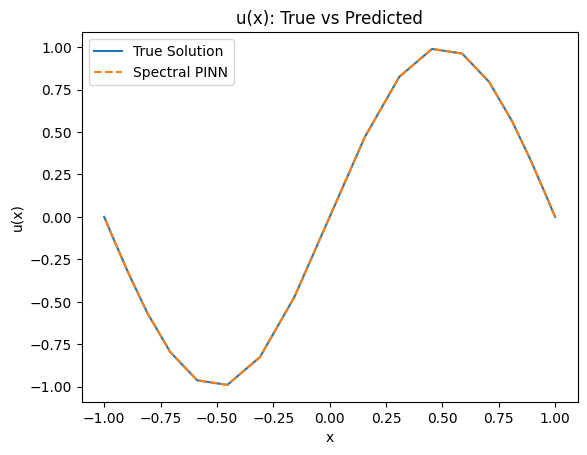

In [221]:
import matplotlib.pyplot as plt

# True solution
u_true = torch.sin(torch.pi * x)

# Predicted solution
c = model()
u_pred = Phi @ c

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.plot(x.detach().cpu().numpy(),
        u_true.detach().cpu().numpy(),
        label="True Solution")

plt.plot(x.detach().cpu().numpy(),
        u_pred.detach().cpu().numpy(),
        '--',
        label="Spectral PINN")

plt.legend()
plt.title("u(x): True vs Predicted")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.show()

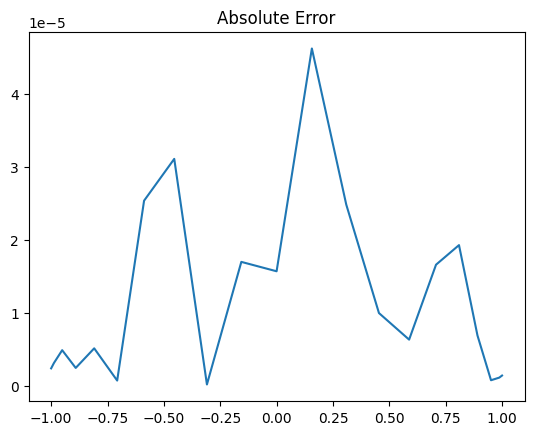

In [ ]:
error = torch.abs(u_pred - u_true)

plt.figure()
plt.plot(x.detach().cpu().numpy(),
        error.detach().cpu().numpy())
plt.title("Absolute Error")
plt.show()

In [224]:
abs_error = torch.abs(u_pred - u_true)
sum_abs_error = torch.sum(abs_error).item()
print("Sum of absolute errors:", sum_abs_error)

Sum of absolute errors: 0.000241065863519907
